# ScamSleuth — Dataset Exploration & Audit

This notebook explores the frozen ScamSleuth Dataset v1.2 before any preprocessing or model training.

The purpose of this audit is to:

- understand the dataset structure,
- verify class balance and data quality,
- identify possible leakage or dataset artifacts,
- inspect template-cluster organization,
- and establish a reliable foundation for later model development.

The dataset is considered frozen before model training.

In [83]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA_PATH = Path("../data/raw/scamsleuth_dataset_v1.2_final.csv")

df = pd.read_csv(DATA_PATH, encoding="cp1252")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (600, 10)


In [84]:
df.head()

,id,text_type,text,label,difficulty,scam_category,template_cluster,strong_signals,weak_signals,label_reason
0,SS0001,job_posting,Cybersecurity Intern | BrightRoute Energy\r\n\...,Safe,Easy,not_applicable,legitimate_job_posting_unpaid_university_resea...,Clear unpaid scope; academic supervision,Unpaid internship,The communication contains clear unpaid scope;...
1,SS0002,email,Subject: Next step for your Machine Learning I...,Safe,Medium,not_applicable,legitimate_email_official_background_screening_09,Post-offer background check; consent stated,Third-party screening vendor,The communication contains post-offer backgrou...
2,SS0003,job_posting,Meadowline Clinics â€” Business Intelligence A...,Safe,Hard,not_applicable,legitimate_job_posting_clinic_receptionist_per...,In-person verification; ordinary CV request,Personal email; limited website,The communication contains in-person verificat...
3,SS0004,email,"Ahmed,\r\n\r\nThe procurement assessment requi...",Scam,Medium,other_recruitment_fraud,fraud_email_gift_card_vendor_validation_13,Improper benefit extracted through a deceptive...,Procurement terminology,The recruitment framing is used to obtain gift...
4,SS0005,email,Subject: Recruitment Coordinator â€” recruitme...,Safe,Medium,not_applicable,legitimate_email_official_background_screening_09,Post-offer background check; consent stated,Third-party screening vendor,The communication contains post-offer backgrou...


In [85]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (600, 10)

Columns:
['id', 'text_type', 'text', 'label', 'difficulty', 'scam_category', 'template_cluster', 'strong_signals', 'weak_signals', 'label_reason']


## 2. Basic Data Quality Checks

Before analyzing patterns or training a model, we verify that the dataset does not contain missing values, duplicate records, invalid identifiers, or unexpected data types.

These checks help ensure that later model results are not affected by basic data-quality problems.

In [86]:
print("Dataset information:\n")
df.info()

Dataset information:

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   id                600 non-null    str  
 1   text_type         600 non-null    str  
 2   text              600 non-null    str  
 3   label             600 non-null    str  
 4   difficulty        600 non-null    str  
 5   scam_category     600 non-null    str  
 6   template_cluster  600 non-null    str  
 7   strong_signals    600 non-null    str  
 8   weak_signals      600 non-null    str  
 9   label_reason      600 non-null    str  
dtypes: str(10)
memory usage: 47.0 KB


In [87]:
duplicate_rows = df.duplicated().sum()

print("Exact duplicate rows:", duplicate_rows)

Exact duplicate rows: 0


In [88]:
duplicate_ids = df["id"].duplicated().sum()
unique_ids = df["id"].nunique()

print("Unique IDs:", unique_ids)
print("Duplicate IDs:", duplicate_ids)

Unique IDs: 600
Duplicate IDs: 0


In [89]:
categorical_columns = [
    "text_type",
    "label",
    "difficulty"
]

for column in categorical_columns:
    print(f"\nUnique values in '{column}':")
    print(df[column].unique())


Unique values in 'text_type':
<StringArray>
['job_posting', 'email', 'message']
Length: 3, dtype: str

Unique values in 'label':
<StringArray>
['Safe', 'Scam']
Length: 2, dtype: str

Unique values in 'difficulty':
<StringArray>
['Easy', 'Medium', 'Hard']
Length: 3, dtype: str


### Data Quality Conclusion

The dataset contains 600 records and 10 columns.

- No null values were detected.
- No exact duplicate rows were found.
- All 600 IDs are unique.
- The categorical fields contain only the expected values.
- All columns are currently stored as string data.

The dataset passes the initial structural and data-quality checks.

## 3. Class Balance

Class balance shows how many examples belong to each target class.

A heavily imbalanced dataset can make accuracy misleading because a model may achieve a high score simply by predicting the majority class.

For ScamSleuth, we examine the distribution of `Safe` and `Scam` examples before selecting any imbalance-handling strategy.

In [90]:
label_counts = df["label"].value_counts()

print("Label counts:")
print(label_counts)

Label counts:
label
Safe    300
Scam    300
Name: count, dtype: int64


In [91]:
label_percentages = df["label"].value_counts(normalize=True) * 100

print("Label percentages:")
print(label_percentages.round(2))

Label percentages:
label
Safe    50.0
Scam    50.0
Name: proportion, dtype: float64


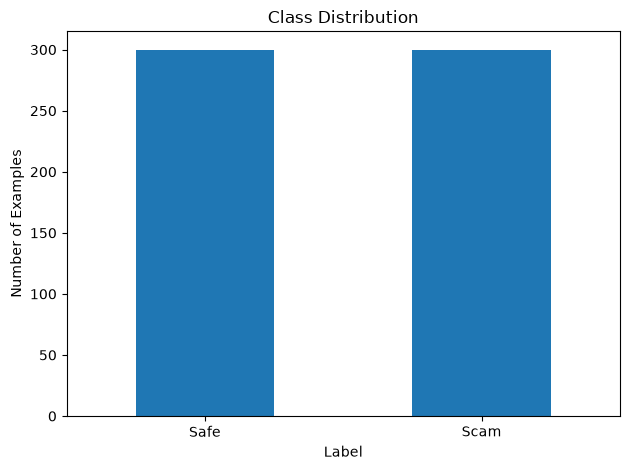

In [92]:
import matplotlib.pyplot as plt

label_counts.plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Examples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Class Balance Conclusion

The dataset is perfectly balanced:

- **Safe:** 300 examples (50%)
- **Scam:** 300 examples (50%)

There is no majority-class imbalance in the current dataset. Therefore, oversampling or undersampling techniques such as SMOTE are not necessary.

During train, validation, and test splitting, class proportions will still be monitored to ensure that both labels remain well represented.

## 4. Text-Type Distribution

ScamSleuth accepts three forms of recruitment-related raw text:

- messages,
- emails,
- job postings.

We examine their distribution to ensure that the model is not trained primarily on one communication format and that both labels are represented across every text type.

In [93]:
text_type_counts = df["text_type"].value_counts()

print("Text type counts:")
print(text_type_counts)

Text type counts:
text_type
job_posting    200
email          200
message        200
Name: count, dtype: int64


In [94]:
text_type_percentages = (
    df["text_type"].value_counts(normalize=True) * 100
)

print("\nText type percentages:")
print(text_type_percentages.round(2))


Text type percentages:
text_type
job_posting    33.33
email          33.33
message        33.33
Name: proportion, dtype: float64


In [95]:
text_type_label_counts = pd.crosstab(
    df["text_type"],
    df["label"]
)

print(text_type_label_counts)

label        Safe  Scam
text_type              
email         100   100
job_posting   100   100
message       100   100


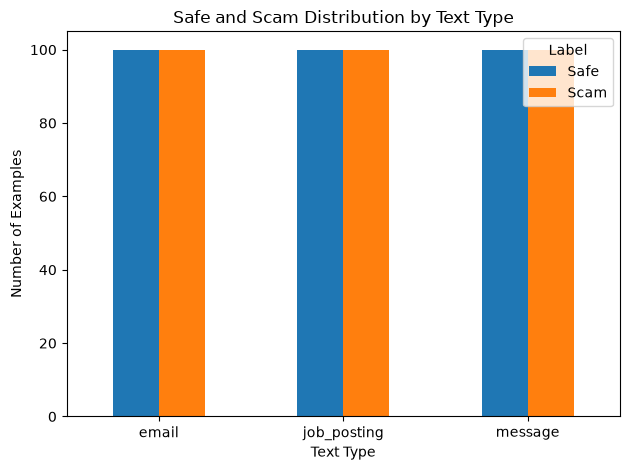

In [96]:
text_type_label_counts.plot(
    kind="bar"
)

plt.title("Safe and Scam Distribution by Text Type")
plt.xlabel("Text Type")
plt.ylabel("Number of Examples")
plt.xticks(rotation=0)
plt.legend(title="Label")
plt.tight_layout()
plt.show()

### Text-Type Distribution Conclusion

The dataset contains an equal number of Safe and Scam examples for every supported text type:

- **Email:** 100 Safe, 100 Scam
- **Job Posting:** 100 Safe, 100 Scam
- **Message:** 100 Safe, 100 Scam

This balanced structure helps reduce the risk that the model learns communication format as a shortcut for predicting the target label.

## 5. Difficulty Distribution

The dataset includes `Easy`, `Medium`, and `Hard` examples.

Difficulty is not used as a model feature. It is included only for analysis so that we can later evaluate whether the classifier performs differently on obvious versus subtle recruitment scams.

In [97]:
difficulty_counts = df["difficulty"].value_counts()

print("Difficulty counts:")
print(difficulty_counts)

print("\nDifficulty percentages:")
print((difficulty_counts / len(df) * 100).round(2))

Difficulty counts:
difficulty
Medium    240
Easy      180
Hard      180
Name: count, dtype: int64

Difficulty percentages:
difficulty
Medium    40.0
Easy      30.0
Hard      30.0
Name: count, dtype: float64


In [98]:
difficulty_label_counts = pd.crosstab(
    df["difficulty"],
    df["label"]
)

print(difficulty_label_counts)

label       Safe  Scam
difficulty            
Easy          90    90
Hard          90    90
Medium       120   120


In [99]:
difficulty_text_type_counts = pd.crosstab(
    df["text_type"],
    df["difficulty"]
)

print(difficulty_text_type_counts)

difficulty   Easy  Hard  Medium
text_type                      
email          60    60      80
job_posting    60    60      80
message        60    60      80


### Difficulty Distribution Conclusion

The dataset contains a balanced difficulty structure:

- **Easy:** 180 examples (30%)
- **Medium:** 240 examples (40%)
- **Hard:** 180 examples (30%)

Each difficulty level is evenly divided between Safe and Scam examples, and the same distribution is preserved across messages, emails, and job postings.

The `difficulty` column will not be used as a model feature. It will be retained only for subgroup evaluation so that model performance can later be compared on obvious and subtle cases.

## 6. Scam Category Distribution

Scam examples are divided into different recruitment-fraud categories.

This analysis checks whether the dataset covers a broad range of scam strategies rather than allowing one category to dominate the Scam class.

The `scam_category` field is used only for analysis and will not be used as a model feature.

In [100]:
scam_only = df[df["label"] == "Scam"]

scam_category_counts = scam_only["scam_category"].value_counts()

print("Scam category counts:")
print(scam_category_counts)

Scam category counts:
scam_category
other_recruitment_fraud           40
upfront_payment                   40
credential_theft                  35
fake_offer                        30
identity_document_misuse          30
money_mule                        20
cheque_overpayment                15
company_impersonation             15
fake_training_or_certification    15
visa_or_processing_fee            15
equipment_purchase                15
suspicious_application_link       15
unrealistic_compensation          15
Name: count, dtype: int64


In [101]:
scam_category_percentages = (
    scam_only["scam_category"].value_counts(normalize=True) * 100
)

print("\nScam category percentages:")
print(scam_category_percentages.round(2))


Scam category percentages:
scam_category
other_recruitment_fraud           13.33
upfront_payment                   13.33
credential_theft                  11.67
fake_offer                        10.00
identity_document_misuse          10.00
money_mule                         6.67
cheque_overpayment                 5.00
company_impersonation              5.00
fake_training_or_certification     5.00
visa_or_processing_fee             5.00
equipment_purchase                 5.00
suspicious_application_link        5.00
unrealistic_compensation           5.00
Name: proportion, dtype: float64


In [102]:
scam_category_by_type = pd.crosstab(
    scam_only["scam_category"],
    scam_only["text_type"]
)

print(scam_category_by_type)

text_type                       email  job_posting  message
scam_category                                              
cheque_overpayment                  5            5        5
company_impersonation               5            5        5
credential_theft                   15           10       10
equipment_purchase                  5            5        5
fake_offer                         10           10       10
fake_training_or_certification      5            5        5
identity_document_misuse           10           10       10
money_mule                         10            5        5
other_recruitment_fraud            10           15       15
suspicious_application_link         5            5        5
unrealistic_compensation            5            5        5
upfront_payment                    10           15       15
visa_or_processing_fee              5            5        5


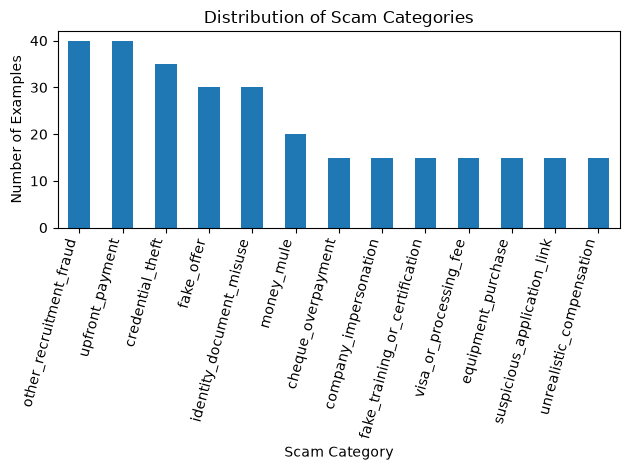

In [103]:
scam_category_counts.plot(kind="bar")

plt.title("Distribution of Scam Categories")
plt.xlabel("Scam Category")
plt.ylabel("Number of Examples")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

### Scam Category Distribution Conclusion

The 300 Scam examples cover 13 different recruitment-fraud categories.

The two largest categories, `other_recruitment_fraud` and `upfront_payment`, each represent 13.33% of Scam examples. No individual category exceeds 20% of the Scam class.

The dataset therefore contains broad coverage of different fraud strategies rather than being dominated by a single scam type.

The `scam_category` column will not be used as a model feature. It will instead be retained for subgroup evaluation and error analysis.

## 7. Template Cluster Audit

The dataset includes a `template_cluster` field that groups examples sharing a similar recruitment scenario, communication structure, or scam strategy.

These clusters will later be used for group-aware dataset splitting so that closely related variants cannot appear in both training and evaluation sets.

This helps reduce template leakage and provides a more realistic estimate of model generalization.

In [104]:
cluster_sizes = df.groupby("template_cluster").size()

print("Number of unique template clusters:", df["template_cluster"].nunique())
print("Minimum cluster size:", cluster_sizes.min())
print("Maximum cluster size:", cluster_sizes.max())
print("Average cluster size:", round(cluster_sizes.mean(), 2))

Number of unique template clusters: 120
Minimum cluster size: 5
Maximum cluster size: 5
Average cluster size: 5.0


In [105]:
cluster_label_counts = (
    df.groupby("template_cluster")["label"]
    .nunique()
)

mixed_label_clusters = (cluster_label_counts > 1).sum()

print("Clusters containing multiple labels:", mixed_label_clusters)

Clusters containing multiple labels: 0


In [106]:
cluster_type_counts = (
    df.groupby("template_cluster")["text_type"]
    .nunique()
)

mixed_type_clusters = (cluster_type_counts > 1).sum()

print("Clusters containing multiple text types:", mixed_type_clusters)

Clusters containing multiple text types: 0


In [107]:
scam_cluster_categories = (
    df[df["label"] == "Scam"]
    .groupby("template_cluster")["scam_category"]
    .nunique()
)

mixed_category_clusters = (scam_cluster_categories > 1).sum()

print(
    "Scam clusters containing multiple scam categories:",
    mixed_category_clusters
)

Scam clusters containing multiple scam categories: 0


In [108]:
cluster_level = df.drop_duplicates("template_cluster")

cluster_distribution = pd.crosstab(
    cluster_level["text_type"],
    cluster_level["label"]
)

print(cluster_distribution)

label        Safe  Scam
text_type              
email          20    20
job_posting    20    20
message        20    20


### Template Cluster Conclusion

The dataset contains 120 unique template clusters, with exactly 5 examples in each cluster.

- No cluster contains multiple labels.
- No cluster contains multiple text types.
- No Scam cluster contains multiple scam categories.
- Each text type contains 20 Safe and 20 Scam clusters.

This structure supports group-aware train, validation, and test splitting. Keeping complete template clusters within a single partition will help prevent closely related examples from leaking across training and evaluation sets.

## 8. Text Length Analysis

Text length can accidentally become a shortcut for classification if one label systematically contains longer or shorter examples.

We therefore compare word and character lengths across Safe and Scam examples, both overall and within each text type.

The goal is not for the distributions to be identical, but they should overlap substantially enough that text length alone does not reveal the target label.

In [109]:
df["word_count"] = df["text"].str.split().str.len()
df["char_count"] = df["text"].str.len()

df[["text", "word_count", "char_count"]].head()

,text,word_count,char_count
0,Cybersecurity Intern | BrightRoute Energy\r\n\...,165,1165
1,Subject: Next step for your Machine Learning I...,204,1503
2,Meadowline Clinics â€” Business Intelligence A...,128,870
3,"Ahmed,\r\n\r\nThe procurement assessment requi...",78,505
4,Subject: Recruitment Coordinator â€” recruitme...,193,1498


In [110]:
length_summary = (
    df.groupby("label")[["word_count", "char_count"]]
    .agg(["mean", "median", "min", "max"])
    .round(2)
)

print(length_summary)

      word_count                 char_count                  
            mean median min  max       mean median  min   max
label                                                        
Safe      141.78  123.0  23  377    1009.15  867.5  156  2629
Scam      142.09  122.0  23  379    1017.90  885.0  152  2687


In [111]:
word_length_by_type = (
    df.groupby(["text_type", "label"])["word_count"]
    .agg(["mean", "median", "min", "max"])
    .round(2)
)

print(word_length_by_type)

                     mean  median  min  max
text_type   label                          
email       Safe   141.94   136.0   50  275
            Scam   143.89   135.0   48  274
job_posting Safe   211.59   213.0   82  377
            Scam   209.90   208.0   84  379
message     Safe    71.81    66.0   23  143
            Scam    72.49    69.0   23  148


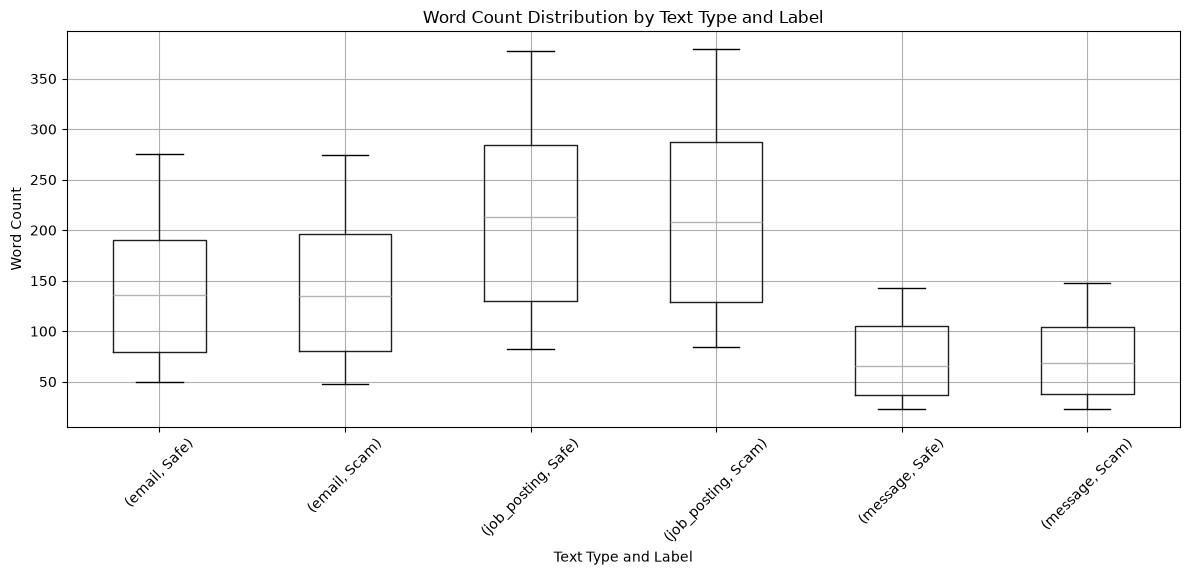

In [112]:
df.boxplot(
    column="word_count",
    by=["text_type", "label"],
    figsize=(12, 6),
    rot=45
)

plt.title("Word Count Distribution by Text Type and Label")
plt.suptitle("")
plt.xlabel("Text Type and Label")
plt.ylabel("Word Count")
plt.tight_layout()
plt.show()

### Text Length Conclusion

Safe and Scam examples have closely overlapping text-length distributions within each supported text type.

- Email averages are approximately 142 words for Safe and 144 words for Scam.
- Job-posting averages are approximately 212 words for Safe and 210 words for Scam.
- Message averages are approximately 72 words for both labels.

The medians, minimums, and maximums also overlap substantially.

This reduces the risk that the classifier can predict the target label simply from text length rather than learning meaningful recruitment-scam patterns.

## 9. URL and Basic Structural Pattern Audit

Recruitment scams may contain suspicious links, unusual formatting, excessive punctuation, or pressure-related structural patterns.

Before engineering these as model features, we inspect their basic distribution across Safe and Scam examples.

The purpose is to ensure that simple structural properties are not already direct shortcuts for the target label.

In [113]:
import re

url_pattern = r"https?://\S+|www\.\S+"

df["url_count"] = df["text"].str.count(url_pattern)

url_by_label = df.groupby("label")["url_count"].agg(
    ["sum", "mean", "median", "max"]
)

print(url_by_label)

       sum      mean  median  max
label                            
Safe   125  0.416667     0.0    1
Scam   125  0.416667     0.0    1


In [114]:
df["has_url"] = df["url_count"] > 0

url_presence = pd.crosstab(
    df["label"],
    df["has_url"]
)

print(url_presence)

has_url  False  True 
label                
Safe       175    125
Scam       175    125


In [115]:
url_by_type = pd.crosstab(
    [df["text_type"], df["label"]],
    df["has_url"]
)

print(url_by_type)

has_url            False  True 
text_type   label              
email       Safe      55     45
            Scam      55     45
job_posting Safe      60     40
            Scam      60     40
message     Safe      60     40
            Scam      60     40


In [116]:
df["exclamation_count"] = df["text"].str.count("!")
df["question_count"] = df["text"].str.count(r"\?")
df["digit_count"] = df["text"].str.count(r"\d")

structural_summary = (
    df.groupby("label")[
        [
            "url_count",
            "exclamation_count",
            "question_count",
            "digit_count"
        ]
    ]
    .mean()
    .round(2)
)

print(structural_summary)

       url_count  exclamation_count  question_count  digit_count
label                                                           
Safe        0.42                0.0            0.05          7.6
Scam        0.42                0.0            0.00          7.4


### URL and Structural Pattern Conclusion

URL presence is evenly distributed across both classes:

- **Safe:** 125 examples with URLs
- **Scam:** 125 examples with URLs

The same balance is preserved across messages, emails, and job postings.

Basic structural properties such as URL count, punctuation, and digit count are also similar between Safe and Scam examples.

This reduces the risk that simple formatting characteristics can directly reveal the target label. URL-related features may still be useful later, but their context and structure will be more important than URL presence alone.

## 10. Manual Sample Inspection

Automated checks cannot fully assess realism, ambiguity, or labeling quality.

A small number of examples are therefore reviewed manually across different labels, text types, and difficulty levels.

This helps identify suspicious annotation patterns, unrealistic wording, or cases where the assigned label does not match the actual recruitment text.

In [117]:
sample_columns = [
    "id",
    "text_type",
    "label",
    "difficulty",
    "scam_category",
    "text",
    "strong_signals",
    "weak_signals",
    "label_reason"
]

manual_sample = (
    df.groupby(["text_type", "label", "difficulty"], group_keys=False)
    .sample(n=1, random_state=42)
)

manual_sample[sample_columns]

for _, row in manual_sample.iterrows():
    print("=" * 100)
    print(f"ID: {row['id']}")
    print(f"Type: {row['text_type']}")
    print(f"Label: {row['label']}")
    print(f"Difficulty: {row['difficulty']}")
    print(f"Scam Category: {row['scam_category']}")
    print("\nTEXT:")
    print(row["text"])
    print("\nStrong Signals:", row["strong_signals"])
    print("Weak Signals:", row["weak_signals"])
    print("Label Reason:", row["label_reason"])
    print()

ID: SS0576
Type: email
Label: Safe
Difficulty: Easy
Scam Category: not_applicable

TEXT:
Re: Administrative Assistant opportunity in London

Hi Hamza,

We will not progress your application for this vacancy, but you may opt into our talent list for six months by replying yes.

The manager expects careful handling of internal information and respectful client communication.

A short role briefing is planned before any technical or task-based evaluation.

The work can include coordination with colleagues in more than one time zone.

Thank you,
Priya Menon

Strong Signals: Clear rejection; consent-based talent pooling
Weak Signals: none
Label Reason: The communication follows a normal recruitment stage supported by clear rejection; consent-based talent pooling. It does not seek payment, credentials, or inappropriate account access.

ID: SS0006
Type: email
Label: Safe
Difficulty: Hard
Scam Category: not_applicable

TEXT:
Subject: Project Coordinator â€” recruitment update

Dear Abdullah,



## 11. Pre-Model Data Quality Corrections

Manual inspection revealed corrupted punctuation caused by character encoding issues, such as `â€”`, `â€“`, and `Â·`.

These artifacts are corrected before model training because they are storage/encoding errors rather than meaningful text. Leaving them in the dataset could cause the text model to learn artificial character patterns.

In [118]:
def repair_mojibake(value):
    if not isinstance(value, str):
        return value

    try:
        return value.encode("cp1252").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        return value


for column in df.columns:
    df[column] = df[column].map(repair_mojibake)

print("Text encoding repaired in memory.")

Text encoding repaired in memory.


In [119]:
encoding_artifacts = [
    "â€”",
    "â€“",
    "â€™",
    "â€œ",
    "â€",
    "Â·"
]

artifact_mask = df["text"].apply(
    lambda text: any(artifact in text for artifact in encoding_artifacts)
)

print("Rows containing encoding artifacts:", artifact_mask.sum())

Rows containing encoding artifacts: 0


In [120]:
remaining_artifacts = 0

for column in df.columns:
    if df[column].dtype == "str":
        remaining_artifacts += df[column].apply(
            lambda value: any(
                artifact in value
                for artifact in encoding_artifacts
            )
        ).sum()

print("Remaining encoding artifacts:", remaining_artifacts)

Remaining encoding artifacts: 0


In [121]:
print(df.loc[df["id"] == "SS0006", "text"].iloc[0][:250])

Subject: Project Coordinator — recruitment update

Dear Abdullah,

Thank you for your interest in the Project Coordinator opportunity associated with Crescent Retail Labs. The position is described as onsite and based around Quetta. The role may 


In [122]:
original_columns = [
    "id",
    "text_type",
    "text",
    "label",
    "difficulty",
    "scam_category",
    "template_cluster",
    "strong_signals",
    "weak_signals",
    "label_reason"
]

df[original_columns].to_csv(
    DATA_PATH,
    index=False,
    encoding="utf-8"
)

In [123]:
test_df = pd.read_csv(DATA_PATH)

print("Shape:", test_df.shape)
print("Columns:", test_df.columns.tolist())

Shape: (600, 10)
Columns: ['id', 'text_type', 'text', 'label', 'difficulty', 'scam_category', 'template_cluster', 'strong_signals', 'weak_signals', 'label_reason']


## 12. Difficulty and Annotation Audit

Manual inspection showed that some difficulty labels may not reflect how obvious or subtle the classification evidence actually is.

Difficulty represents classification difficulty, not the severity of the scam.

- **Easy:** strong and explicit evidence
- **Medium:** multiple signals or some contextual reasoning required
- **Hard:** subtle, ambiguous, or realistic-looking examples where the label is not immediately obvious

Potential inconsistencies are reviewed before model training.

In [124]:
review_ids = [
    "SS0043",
    "SS0126",
    "SS0399",
    "SS0294",
    "SS0041",
    "SS0172"
]

review_rows = df[
    df["id"].isin(review_ids)
][
    [
        "id",
        "label",
        "difficulty",
        "scam_category",
        "text",
        "strong_signals",
        "weak_signals",
        "label_reason"
    ]
]

for _, row in review_rows.iterrows():
    print("=" * 100)
    print("ID:", row["id"])
    print("Label:", row["label"])
    print("Current Difficulty:", row["difficulty"])
    print("Category:", row["scam_category"])
    print("\nTEXT:")
    print(row["text"])
    print("\nStrong Signals:", row["strong_signals"])
    print("Weak Signals:", row["weak_signals"])
    print("Reason:", row["label_reason"])
    print()

ID: SS0041
Label: Scam
Current Difficulty: Easy
Category: fake_offer

TEXT:
Candidate update | Orchid Support Services

Ali,

Thank you for your interest in the Recruitment Coordinator opportunity associated with Orchid Support Services. The position is described as remote and based around Lahore. The board has appointed you without an interview or application. Sign the attached generic letter and return only the signature page.

The current compensation indication is PKR 90,000–120,000 per month. Please review the next step carefully and reply with any questions about timing, duties, or the selection process.

The hiring contact expects to complete this stage near 20 August. Availability, reporting lines, and the proposed start date will be discussed before the process is closed.

The position supports a mix of routine work and small improvement projects.

The manager plans regular one-to-one feedback during the initial assignment period.

The team uses documented procedures but allow

In [125]:
hard_scams = df[
    (df["label"] == "Scam") &
    (df["difficulty"] == "Hard")
].copy()

obvious_terms = [
    "password",
    "one-time code",
    "otp",
    "bank account",
    "banking credentials",
    "card number",
    "pay ",
    "payment",
    "buy ",
    "purchase",
    "transfer",
    "forward the money",
    "gift card"
]

def find_obvious_terms(text):
    text_lower = text.lower()

    return [
        term
        for term in obvious_terms
        if term in text_lower
    ]

hard_scams["obvious_terms_found"] = (
    hard_scams["text"].apply(find_obvious_terms)
)

hard_review = hard_scams[
    hard_scams["obvious_terms_found"].str.len() > 0
]

print(
    "Hard Scam examples containing potentially explicit signals:",
    len(hard_review)
)

hard_review[
    [
        "id",
        "scam_category",
        "obvious_terms_found"
    ]
]

Hard Scam examples containing potentially explicit signals: 30


,id,scam_category,obvious_terms_found
25,SS0026,upfront_payment,[transfer]
42,SS0043,credential_theft,"[password, one-time code]"
69,SS0070,upfront_payment,[purchase]
70,SS0071,credential_theft,"[password, one-time code]"
117,SS0118,credential_theft,[transfer]
132,SS0133,credential_theft,"[password, one-time code]"
150,SS0151,credential_theft,[banking credentials]
175,SS0176,upfront_payment,"[purchase, transfer]"
203,SS0204,money_mule,[payment]
249,SS0250,upfront_payment,[purchase]


In [126]:
difficulty_updates = {
    "SS0043": "Easy",
    "SS0126": "Medium",
    "SS0399": "Easy",
    "SS0294": "Easy",
}

for row_id, new_difficulty in difficulty_updates.items():
    df.loc[df["id"] == row_id, "difficulty"] = new_difficulty

print(
    df[df["id"].isin(difficulty_updates.keys())][
        ["id", "difficulty"]
    ]
)

         id difficulty
42   SS0043       Easy
125  SS0126     Medium
293  SS0294       Easy
398  SS0399       Easy


In [127]:
df.loc[
    df["id"] == "SS0172",
    "label_reason"
] = (
    "The recruitment assessment requires a complete client-ready campaign "
    "that will be delivered immediately, allowing the supposed employer to "
    "obtain usable production work without a genuine hiring process."
)

In [128]:
mask = df["id"] == "SS0041"

df.loc[mask, "text"] = (
    df.loc[mask, "text"]
    .str.replace(
        "The recruiter expects the selection process to include at least one live conversation.",
        "",
        regex=False
    )
)

print(df.loc[mask, "text"].iloc[0])

Candidate update | Orchid Support Services

Ali,

Thank you for your interest in the Recruitment Coordinator opportunity associated with Orchid Support Services. The position is described as remote and based around Lahore. The board has appointed you without an interview or application. Sign the attached generic letter and return only the signature page.

The current compensation indication is PKR 90,000–120,000 per month. Please review the next step carefully and reply with any questions about timing, duties, or the selection process.

The hiring contact expects to complete this stage near 20 August. Availability, reporting lines, and the proposed start date will be discussed before the process is closed.

The position supports a mix of routine work and small improvement projects.

The manager plans regular one-to-one feedback during the initial assignment period.

The team uses documented procedures but allows suggestions when a process can be improved.

Applicants may be asked how t

In [129]:
remaining_hard_review = hard_review[
    ~hard_review["id"].isin(
        ["SS0043", "SS0126"]
    )
].copy()

for _, row in remaining_hard_review.iterrows():
    print("=" * 100)
    print(
        f"{row['id']} | "
        f"{row['scam_category']} | "
        f"{row['obvious_terms_found']}"
    )
    print()
    print(row["text"])
    print()

SS0026 | upfront_payment | ['transfer']

Data Annotation Specialist | Maple & Byte Studio

Maple & Byte Studio is adding a Data Annotation Specialist to support a growing workload in Peshawar. Create a wallet at https://remote-onboarding-maple-and-byte-studio.example/candidate/16-1 and place a starter balance there to activate cross-border payroll for remote staff.

What you will do
- Keep accurate records and communicate progress.
- Coordinate assigned tasks with the team lead.
- Raise issues early and follow documented procedures.

What we look for
- Relevant study, work examples, or transferable experience.
- Reliable availability and clear written communication.

SS0070 | upfront_payment | ['purchase']

Career opportunity in Quetta: Administrative Assistant

Role summary
The Administrative Assistant supports colleagues across operations and project delivery. Purchase the remote security licence from https://remote-onboarding-beaconfox-technologies.example/candidate/19-4; reimbursem

In [130]:
difficulty_updates = {
    # Easy — explicit fraudulent action
    "SS0071": "Easy",
    "SS0118": "Easy",
    "SS0133": "Easy",
    "SS0151": "Easy",
    "SS0204": "Easy",
    "SS0253": "Easy",
    "SS0284": "Easy",
    "SS0314": "Easy",
    "SS0377": "Easy",
    "SS0385": "Easy",
    "SS0467": "Easy",
    "SS0488": "Easy",
    "SS0504": "Easy",
    "SS0518": "Easy",
    "SS0592": "Easy",

    # Medium — fraudulent request hidden inside plausible process
    "SS0026": "Medium",
    "SS0070": "Medium",
    "SS0176": "Medium",
    "SS0250": "Medium",
    "SS0287": "Medium",
    "SS0288": "Medium",
    "SS0290": "Medium",
    "SS0328": "Medium",
    "SS0361": "Medium",
    "SS0505": "Medium",
    "SS0525": "Medium",
    "SS0530": "Medium",
}

for row_id, new_difficulty in difficulty_updates.items():
    df.loc[df["id"] == row_id, "difficulty"] = new_difficulty

In [131]:
df.loc[df["id"] == "SS0043", "difficulty"] = "Easy"
df.loc[df["id"] == "SS0126", "difficulty"] = "Medium"
df.loc[df["id"] == "SS0294", "difficulty"] = "Easy"
df.loc[df["id"] == "SS0399", "difficulty"] = "Easy"

In [132]:
ss0041_text = """Candidate update | Orchid Support Services

Ali,

The board has approved your appointment as Recruitment Coordinator with Orchid Support Services for a remote position connected to Lahore. No interview or further application stage is required.

The proposed compensation is PKR 90,000–120,000 per month. Please sign the attached appointment letter and return only the signature page so HR can activate your employee record.

Once the signed page is received, the onboarding team will send your reporting details, start date, and orientation instructions. Training materials will be provided during the opening week.

Kind regards,
Imran Baig
Recruitment"""

df.loc[df["id"] == "SS0041", "text"] = ss0041_text

In [133]:
df.loc[
    df["id"] == "SS0172",
    "label_reason"
] = (
    "The recruitment assessment requires a complete client-ready campaign "
    "that will be delivered immediately, allowing the supposed employer to "
    "obtain usable production work without a genuine hiring process."
)

In [134]:
difficulty_counts_after_audit = df["difficulty"].value_counts()

print("Difficulty distribution after audit:")
print(difficulty_counts_after_audit)

print("\nPercentages:")
print(
    (difficulty_counts_after_audit / len(df) * 100)
    .round(2)
)

Difficulty distribution after audit:
difficulty
Medium    251
Easy      198
Hard      151
Name: count, dtype: int64

Percentages:
difficulty
Medium    41.83
Easy      33.00
Hard      25.17
Name: count, dtype: float64


In [135]:
print(
    pd.crosstab(
        df["difficulty"],
        df["label"]
    )
)

label       Safe  Scam
difficulty            
Easy          90   108
Hard          90    61
Medium       120   131


In [136]:
original_columns = [
    "id",
    "text_type",
    "text",
    "label",
    "difficulty",
    "scam_category",
    "template_cluster",
    "strong_signals",
    "weak_signals",
    "label_reason"
]

df[original_columns].to_csv(
    DATA_PATH,
    index=False,
    encoding="utf-8"
)

In [137]:
check_df = pd.read_csv(DATA_PATH)

print("Shape:", check_df.shape)
print("Duplicates:", check_df.duplicated().sum())
print("Missing values:", check_df.isnull().sum().sum())

Shape: (600, 10)
Duplicates: 0
Missing values: 0


## 13. Phase 1 Audit Summary

The ScamSleuth dataset was audited before model training.

Key findings:

- The dataset contains 600 rows and 10 columns.
- No missing values or exact duplicate rows were found.
- All 600 IDs are unique.
- The target labels are balanced: 300 Safe and 300 Scam.
- Messages, emails, and job postings are evenly represented.
- Safe and Scam examples are balanced within each text type.
- Scam examples cover 13 different recruitment-fraud categories.
- The dataset contains 120 template clusters, with 5 examples per cluster.
- No template cluster mixes labels, text types, or Scam categories.
- Safe and Scam text-length distributions overlap closely within every text type.
- URL presence is balanced across both labels.
- Encoding artifacts were removed and the dataset was normalized to UTF-8.
- Manual inspection identified and corrected several inconsistent difficulty annotations.
- One contradictory synthetic example was rewritten for internal consistency.
- One overly generic annotation was corrected to match the actual recruitment scenario.

After difficulty auditing, the distribution is:

- Easy: 198
- Medium: 251
- Hard: 151

The dataset is now considered ready for leakage-aware splitting and subsequent model development.